
# Fitting a 2D Gaussian using DeepTrack and PyTorch Gradients

This notebook demonstrates how to leverage DeepTrack's integration with PyTorch for automatic differentiation. We define a simple image generation pipeline using DeepTrack features and then use PyTorch's optimizers to fit the parameters of this pipeline to a target image.


In [1]:

import deeptrack as dt
from deeptrack.backend import xp # xp provides backend-agnostic numpy-like functions (e.g., torch.exp or np.exp)

# Set the backend to PyTorch to enable gradient computation
config = dt.backend.config
config.set_backend("torch")


c:\Users\GU\DeepTrack\DeepTrack-2.0\deeptrack\__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(


## Defining Custom DeepTrack Features

Below, we define two custom features: `Gaussian2d` creates a 2D Gaussian distribution, and `Grid2d` creates the coordinate grid needed for the Gaussian calculation. Note the use of `xp` for array operations, ensuring compatibility with the chosen backend (PyTorch in this case).

In [12]:
class Gaussian2d(dt.Feature):
    """Generates a 2D Gaussian distribution on a grid."""
    def __init__(self, sigma=(1, 1), mu=(0, 0), amplitude=1):
        super().__init__(sigma=sigma, mu=mu, amplitude=amplitude)

    def get(self, xygrid, sigma, mu, amplitude, **kwargs):
        exponent_x = (xygrid[0] - mu[0]) ** 2 / (2 * sigma[0] ** 2)
        exponent_y = (xygrid[1] - mu[1]) ** 2 / (2 * sigma[1] ** 2)
        return amplitude * xp.exp(-(exponent_x + exponent_y))


class Grid2d(dt.Feature):
    """Generates a 2D coordinate grid."""
    __distributed__ = False # Optional: Hint for distributed execution

    def __init__(self, shape=(64, 64), xlim=(-1, 1), ylim=(-1, 1)):
        super().__init__(shape=shape, xlim=xlim, ylim=ylim)

    def get(self, _, shape, xlim, ylim, **kwargs):
        x = xp.linspace(xlim[0], xlim[1], shape[0])
        y = xp.linspace(ylim[0], ylim[1], shape[1])
        X, Y = xp.meshgrid(x, y)
        return xp.stack([X, Y], axis=0) # Returns a (2, shape[0], shape[1]) tensor


We chain the `Grid2d` and `Gaussian2d` features using the `>>` operator to create an image generation pipeline. We then define the specific parameters for our target Gaussian and call the pipeline to generate the `target_image`. This image will serve as the ground truth for our optimization process.

In [3]:
gaussian_image = Grid2d() >> Gaussian2d()

target_sigma = (0.1, 0.15)
target_mu = (0.2, -0.1)
target_amplitude = 0.8

target_image = gaussian_image(
    sigma=target_sigma, mu=target_mu, amplitude=target_amplitude
)

c:\Users\GU\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]



A quick visualization using `matplotlib` to see what the target image looks like.

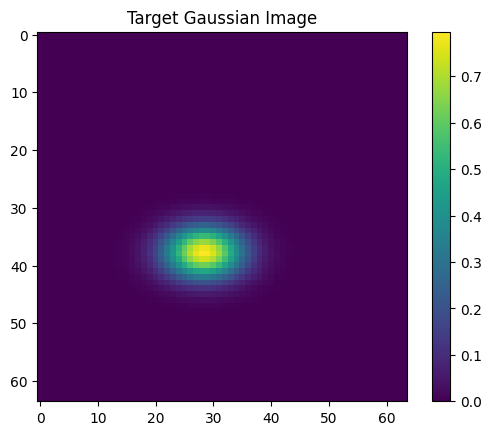

In [13]:
import matplotlib.pyplot as plt

plt.imshow(target_image.cpu().numpy()) # Use .cpu().numpy() if using PyTorch tensors on GPU
plt.colorbar()
plt.title("Target Gaussian Image")
plt.show()

Here, we prepare for the optimization.
1.  Define `sigma`, `mu`, and `amplitude` as `torch.nn.Parameter`. This tells PyTorch that these are tensors whose values we want to optimize. We initialize them with arbitrary starting values.
2.  Create a new `training_feature` pipeline, similar to the one used for the target image, but this time passing the trainable `torch.nn.Parameter` objects as arguments. DeepTrack automatically handles these parameters within the pipeline.
3.  Instantiate a PyTorch optimizer (`Adam` in this case), passing the parameters we want it to train.

In [14]:
import torch

# Define trainable parameters with initial guesses
sigma = torch.nn.Parameter(torch.tensor([0.1, 0.1]))
mu = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
amplitude = torch.nn.Parameter(torch.tensor(1.0))

# Create the training pipeline using the trainable parameters
training_feature = Grid2d() >> Gaussian2d(
    sigma=sigma,
    mu=mu,
    amplitude=amplitude,
)

# Define the optimizer
optimizer = torch.optim.Adam(
    [sigma, mu, amplitude], # List of parameters to optimize
    lr=0.01, # Learning rate
)

This is the core optimization loop. In each iteration:
1.  `training_feature.update()()`: We call the training pipeline. `.update()` ensures any internal state is refreshed (important since the change in parameters does not automatically invalidate the graph), and `()` executes the pipeline. This generates an image using the *current* values of `sigma`, `mu`, and `amplitude`.
2.  `torch.nn.functional.mse_loss`: Calculate the Mean Squared Error between the currently generated image and the `target_image`. This is our loss function.
3.  `optimizer.zero_grad()`: Clear any gradients accumulated from previous iterations.
4.  `loss.backward()`: Compute the gradients of the loss with respect to all trainable parameters (`sigma`, `mu`, `amplitude`). PyTorch tracks the operations and automatically calculates these gradients.
5.  `optimizer.step()`: Update the values of the parameters based on the computed gradients and the optimizer's algorithm (Adam).
6.  We store and print the loss periodically to monitor progress.

In [15]:
losses = []
num_iterations = 100
for i in range(num_iterations):
    # Generate image with current parameters
    image = training_feature.update()()

    # Calculate loss
    loss = torch.nn.functional.mse_loss(image, target_image)

    # Backpropagation and optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logging
    if i % 10 == 0:
        # .data is used to access the tensor data without gradient tracking
        print(
            f"Iteration {i}/{num_iterations}, Loss: {loss.item():.4f}, "
            f"sigma: [{sigma.data[0]:.3f}, {sigma.data[1]:.3f}], "
            f"mu: [{mu.data[0]:.3f}, {mu.data[1]:.3f}], "
            f"amplitude: {amplitude.data:.3f}"
        )
    losses.append(loss.item())


Iteration 0/100, Loss: 0.0104, sigma: [0.090, 0.090], mu: [0.010, -0.010], amplitude: 0.990
Iteration 10/100, Loss: 0.0049, sigma: [0.127, 0.049], mu: [0.106, -0.101], amplitude: 0.910
Iteration 20/100, Loss: 0.0006, sigma: [0.119, 0.124], mu: [0.192, -0.108], amplitude: 0.853
Iteration 30/100, Loss: 0.0004, sigma: [0.087, 0.172], mu: [0.224, -0.088], amplitude: 0.812
Iteration 40/100, Loss: 0.0001, sigma: [0.100, 0.169], mu: [0.195, -0.105], amplitude: 0.774
Iteration 50/100, Loss: 0.0000, sigma: [0.103, 0.151], mu: [0.193, -0.100], amplitude: 0.750
Iteration 60/100, Loss: 0.0000, sigma: [0.106, 0.148], mu: [0.204, -0.099], amplitude: 0.758
Iteration 70/100, Loss: 0.0000, sigma: [0.101, 0.153], mu: [0.201, -0.101], amplitude: 0.777
Iteration 80/100, Loss: 0.0000, sigma: [0.099, 0.153], mu: [0.198, -0.099], amplitude: 0.791
Iteration 90/100, Loss: 0.0000, sigma: [0.101, 0.150], mu: [0.201, -0.101], amplitude: 0.797



## Visualizing Training Loss

Plotting the recorded loss values shows how the error decreased over the training iterations, indicating that the optimization converged.


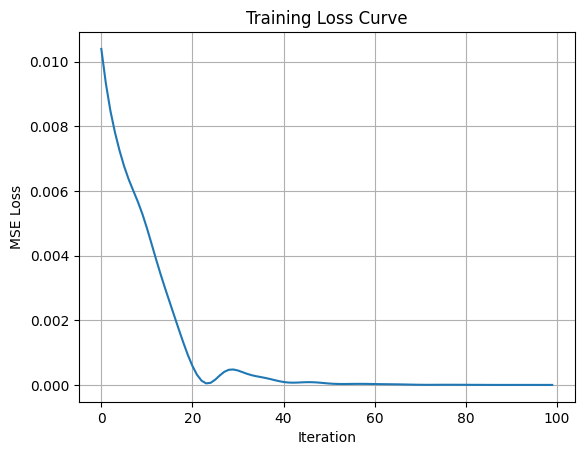

In [16]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()



Finally, we compare the image generated with the final optimized parameters to the original target image.
1.  We get the final trained image from `training_feature.update()()`.
2.  We use `.detach().numpy()` (or `.cpu().detach().numpy()` if on GPU) to convert the PyTorch tensors to NumPy arrays suitable for `matplotlib`.
3.  We display the final trained image and the difference image (Target - Trained). The difference image highlights areas where the fit isn't perfect.

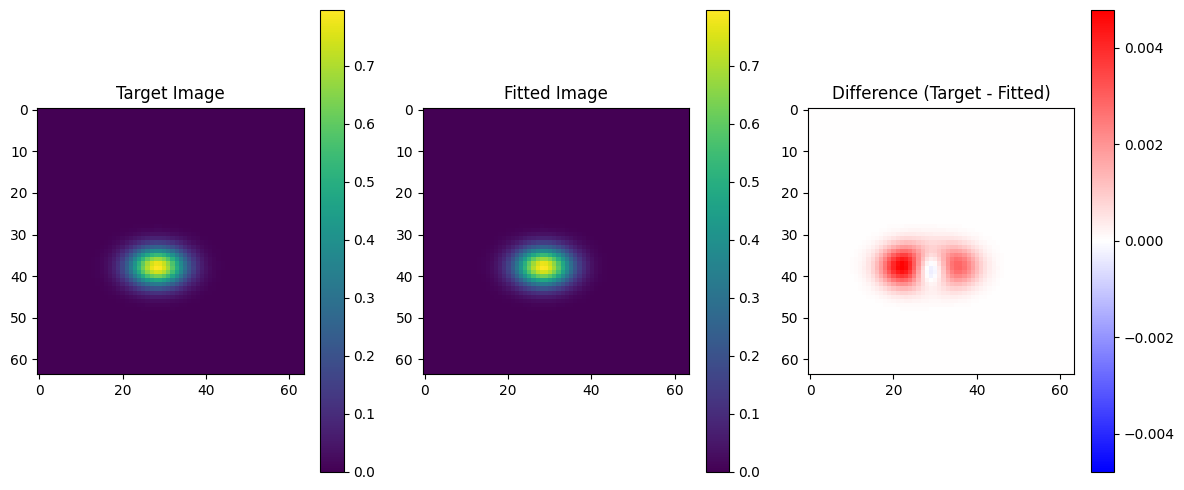


Final Optimized Parameters:
Target sigma:      (0.100, 0.150)
Fitted sigma:      [0.100, 0.149]
Target mu:         (0.200, -0.100)
Fitted mu:         [0.200, -0.100]
Target amplitude:  0.800
Fitted amplitude:  0.800


In [11]:
import numpy as np
# Ensure we are working with numpy arrays on the CPU for plotting
target_np = target_image.cpu().detach().numpy()
# Get the final image from the trained pipeline
training_np = training_feature.update()().cpu().detach().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(target_np)
plt.colorbar()
plt.title("Target Image")

plt.subplot(1, 3, 2)
plt.imshow(training_np)
plt.colorbar()
plt.title("Fitted Image")

plt.subplot(1, 3, 3)
diff = target_np - training_np
vmax = np.max(np.abs(diff))
plt.imshow(diff, cmap="bwr", vmin=-vmax, vmax=vmax) # Use a diverging colormap
plt.colorbar()
plt.title("Difference (Target - Fitted)")

plt.tight_layout()
plt.show()

print("\nFinal Optimized Parameters:")
print(f"Target sigma:      ({target_sigma[0]:.3f}, {target_sigma[1]:.3f})")
print(f"Fitted sigma:      [{sigma.data[0]:.3f}, {sigma.data[1]:.3f}]")
print(f"Target mu:         ({target_mu[0]:.3f}, {target_mu[1]:.3f})")
print(f"Fitted mu:         [{mu.data[0]:.3f}, {mu.data[1]:.3f}]")
print(f"Target amplitude:  {target_amplitude:.3f}")
print(f"Fitted amplitude:  {amplitude.data:.3f}")